In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from routes_preprocessing import *

In [3]:
# Compare 2018 delays (earliest available) to 2024 delays (latest available)
filename_2024 = "../datasets/MBTA-Bus-Arrival-Departure-Times_2024-12.csv"
filename_2018 =  "../datasets/MBTA-Bus-Arrival-Departure-Times_2018-12.csv"

In [4]:
df_2018_percent = pd.read_csv(filename_2018, low_memory=False)
df_2024_percent = pd.read_csv(filename_2024, low_memory=False)

In [ ]:
df_list = []
for df in [df_2018_percent, df_2024_percent]:

    
    df = df[~df['route_id'].astype(str).str.startswith(('600', '700', 'rad', '743', "171", "194"))]

    # Calculate delay
    df['time_difference'] = pd.to_datetime(df['actual']) - pd.to_datetime(df['scheduled'])
    df['delay_seconds'] = df['time_difference'].dt.total_seconds()

    # Remove extreme outliers
    filtered_df = df[(df['delay_seconds'] >= -3600) & (df['delay_seconds'] <= 3600)]

    # Keep only positive delays
    positive_delays = filtered_df[filtered_df['delay_seconds'] > 0]

    # Group by route_id and compute both average positive delay and % over 5 minutes late
    grouped = positive_delays.groupby('route_id')
    result = grouped['delay_seconds'].mean().reset_index(name='avg_positive_delay')
    result['percent_late_gt_5min'] = grouped.apply(lambda x: (x['delay_seconds'] > 300).mean() * 100).values

    df_list.append(result)


df_2018_grouped_percent, df_2024_grouped_percent = df_list

C:\Users\Michael\AppData\Local\Temp\ipykernel_1460\1067701936.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time_difference'] = pd.to_datetime(df['actual']) - pd.to_datetime(df['scheduled'])
C:\Users\Michael\AppData\Local\Temp\ipykernel_1460\1067701936.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['delay_seconds'] = df['time_difference'].dt.total_seconds()
C:\Users\Michael\AppData\Local\Temp\ipykernel_1460\1067701936.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the groupi

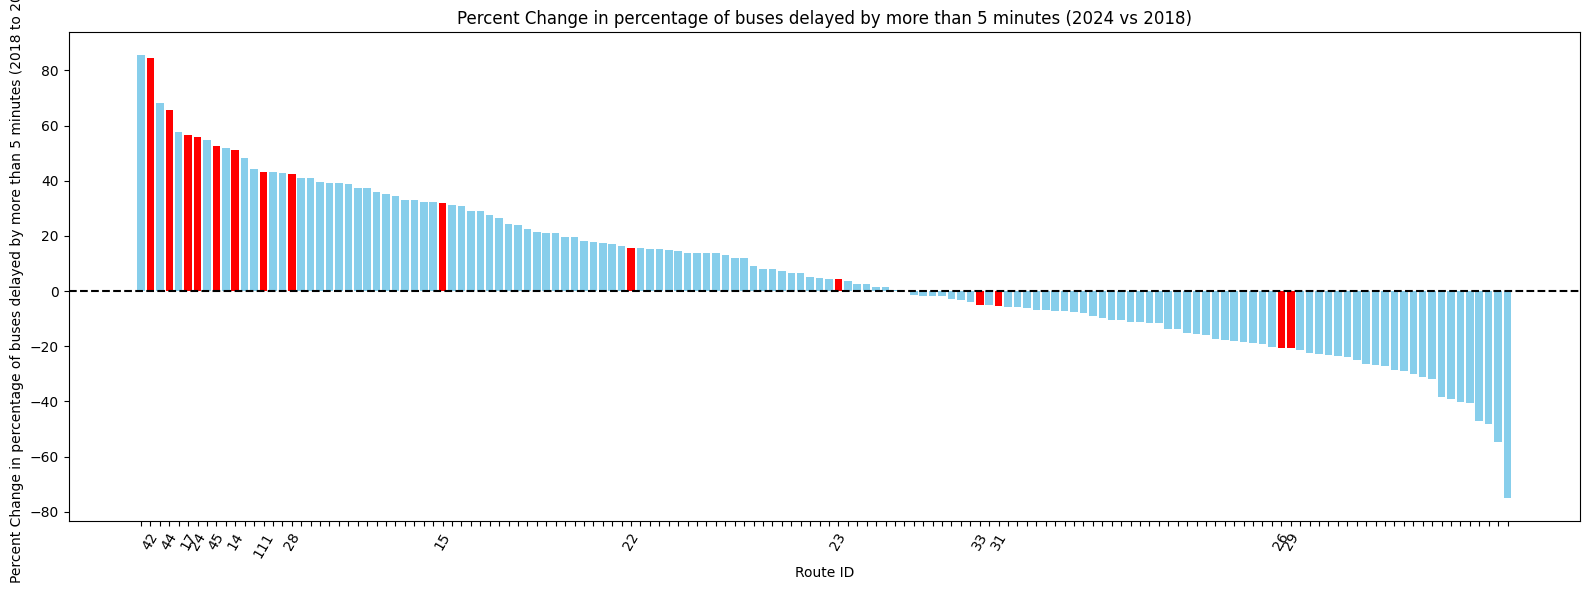

In [6]:
delay_comparison_percent = pd.merge(
    df_2018_grouped_percent,
    df_2024_grouped_percent,
    on='route_id',
    suffixes=('_2018', '_2024')
)

delay_comparison_percent['percent_change'] = (
    (delay_comparison_percent['percent_late_gt_5min_2024'] - delay_comparison_percent['percent_late_gt_5min_2018']) /
    delay_comparison_percent['percent_late_gt_5min_2018']
) * 100
delay_comparison_percent = delay_comparison_percent.sort_values(by='percent_change', ascending=False)


target_routes = {"22", "29", "15", "45", "28", "44", "42", "17", "23", "31", "26", "111", "24", "33", "14"}
colors = ['red' if route in target_routes else 'skyblue' for route in delay_comparison_percent['route_id']]
tick_labels = [route if route in target_routes else '' for route in delay_comparison_percent['route_id']]

plt.figure(figsize=(16, 6))
plt.bar(delay_comparison_percent['route_id'], delay_comparison_percent['percent_change'], color=colors)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Route ID')
plt.ylabel('Percent Change in percentage of buses delayed by more than 5 minutes (2018 to 2024)')
plt.title('Percent Change in percentage of buses delayed by more than 5 minutes (2024 vs 2018)')
plt.xticks(range(len(delay_comparison_percent['route_id'])), tick_labels, rotation=60)
plt.tight_layout()
plt.show()


c:\Users\Michael\Desktop\BU\2025-Spring\CS 506\Final_Project\MBTA-bus-inequity-analysis\bus-delay-time-analysis\routes_preprocessing.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  routes_df['time_difference'] = pd.to_datetime(routes_df['actual']) - pd.to_datetime(routes_df['scheduled'])
c:\Users\Michael\Desktop\BU\2025-Spring\CS 506\Final_Project\MBTA-bus-inequity-analysis\bus-delay-time-analysis\routes_preprocessing.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  routes_df['delay_seconds'] = rout

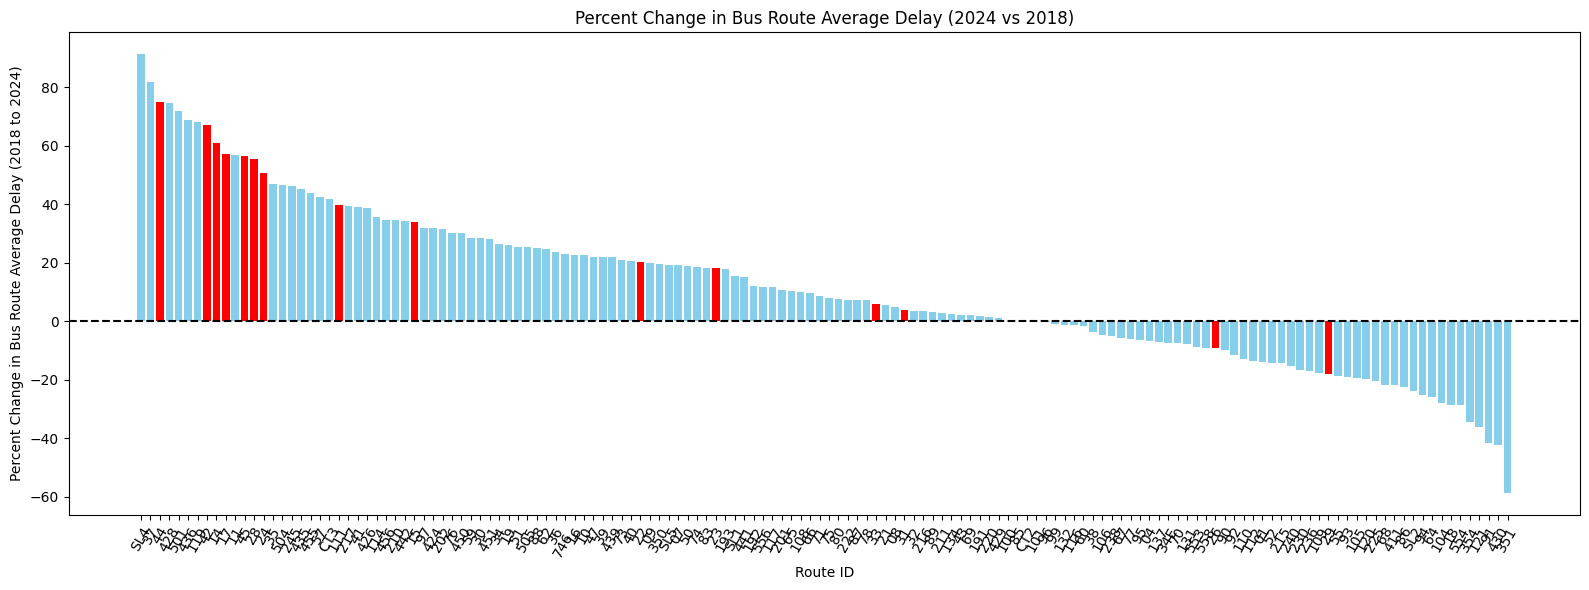

In [8]:
df_2018 = pd.read_csv(filename_2018, low_memory=False)
df_2024 = pd.read_csv(filename_2024, low_memory=False)

df_list = []
for df in [df_2018, df_2024]:
  grouped = preprocess_routes(df)  
  df_list.append(grouped)

df_2018_grouped, df_2024_grouped = df_list

delay_comparison = pd.merge(
    df_2018_grouped,
    df_2024_grouped,
    on='route_id',
    suffixes=('_2018', '_2024')
)

delay_comparison['delay_seconds'] = (
    (delay_comparison['delay_seconds_2024'] - delay_comparison['delay_seconds_2018']) /
    delay_comparison['delay_seconds_2018']
) * 100
delay_comparison = delay_comparison.sort_values(by='delay_seconds', ascending=False)


target_routes = {"22", "29", "15", "45", "28", "44", "42", "17", "23", "31", "26", "111", "24", "33", "14"}
colors = ['red' if route in target_routes else 'skyblue' for route in delay_comparison['route_id']]
tick_labels = [route if route in target_routes else '' for route in delay_comparison['route_id']]

plt.figure(figsize=(16, 6))
plt.bar(delay_comparison['route_id'], delay_comparison['delay_seconds'], color=colors)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Route ID')
plt.ylabel('Percent Change in Bus Route Average Delay (2018 to 2024)')
plt.title('Percent Change in Bus Route Average Delay (2024 vs 2018)')
# plt.xticks(range(len(delay_comparison['route_id'])), tick_labels, rotation=60)
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()
